In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = pd.read_csv(r'C:\Users\bhaga\python\PSCompPars_2026.08.08_04.23.14.csv',comment='#')

threshold = len(df) * 0.5
df_clean = df.dropna(thresh = threshold, axis=1)

key_cols = ['pl_orbper','pl_rade','pl_bmasse','st_teff','st_rad','st_mass']
key_cols = [c for c in key_cols if c in df_clean.columns]
for col in key_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean = df_clean.dropna(subset=['pl_name','disc_year'])
df_clean['disc_year'] = df_clean['disc_year'].astype(int)
print('ready:' ,df_clean.shape)

ready: (6336, 75)


In [9]:
transit_period = df_clean[df_clean['discoverymethod'] == 'Transit']['pl_orbper']
rv_periods = df_clean[df_clean['discoverymethod'] == 'Radial Velocity']['pl_orbper']

print('Transit group size:',len(transit_period))
print('Radial Velocity group size:',len(rv_periods))
print('\nTransit mean orbital period:',transit_period.mean())
print('Radial Velocity mean orbital period:',rv_periods.mean())

Transit group size: 4676
Radial Velocity group size: 1197

Transit mean orbital period: 23.506767968324002
Radial Velocity mean orbital period: 1761.267398761278


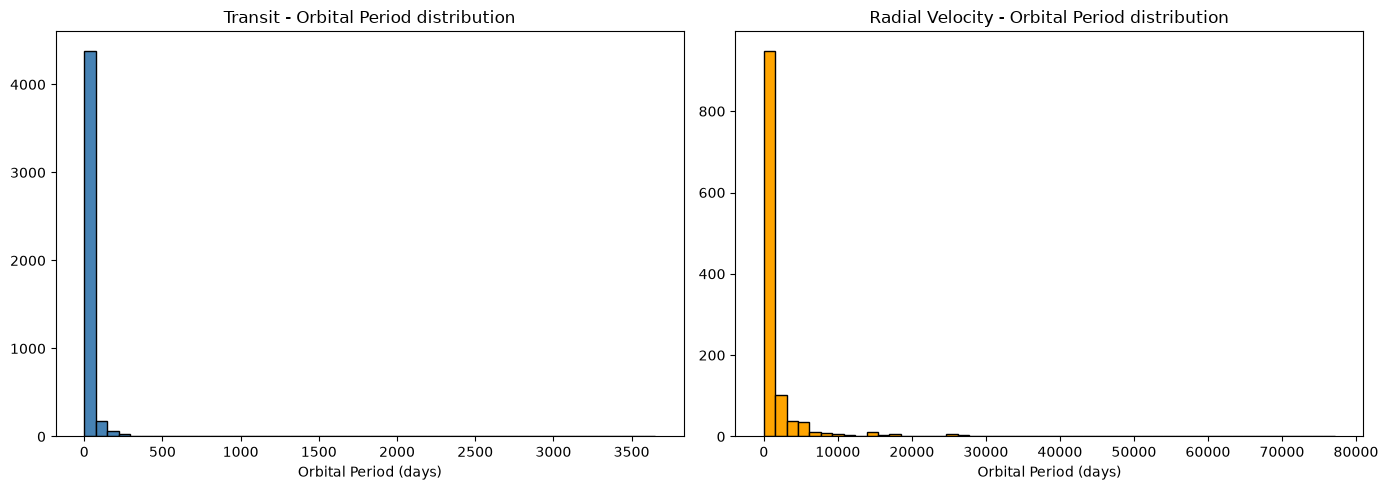

In [10]:
fix, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].hist(transit_period,bins=50,color='steelblue',edgecolor='black')
axes[0].set_title('Transit - Orbital Period distribution')
axes[0].set_xlabel('Orbital Period (days)')

axes[1].hist(rv_periods,bins=50,color='orange',edgecolor='black')
axes[1].set_title('Radial Velocity - Orbital Period distribution')
axes[1].set_xlabel('Orbital Period (days)')

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
transit_log = np.log(transit_period)
rv_log = np.log10(rv_periods)
t_stat,p_value = stats.ttest_ind(transit_log,rv_log,equal_var=False)
print('T-statistic:',t_stat)
print('P-value:',p_value)
alpha = 0.05
if p_value < alpha:
    print('\nResult: Reject the null hypothesis - there is a satistically significnt difference in mean orbital periods between Transit and Radical velocity discoveries.')
else:
    print('\nResult:Fail to reject the null hypothesis - no statistically sigmificant difference found.')

T-statistic: -2.5663327023336326
P-value: 0.010345490070188148

Result: Reject the null hypothesis - there is a satistically significnt difference in mean orbital periods between Transit and Radical velocity discoveries.


In [12]:
from scipy.stats import t
mean_diff = transit_log.mean()-rv_log.mean()
se_diff = np.sqrt(transit_log.var()/len(transit_log) + rv_log.var()/len(rv_log))
df_approx = min(len(transit_log),len(rv_log))-1
ci_low,ci_high = t.interval(0.95,df_approx,loc=mean_diff,scale=se_diff)
print('Mean difference (log scale):',mean_diff)
print('95% Confidence interval:',(ci_low,ci_high))


Mean difference (log scale): -0.09138310695239937
95% Confidence interval: (np.float64(-0.1612450689284009), np.float64(-0.02152114497639783))


In [13]:
print(df_clean['discoverymethod'].unique())

<StringArray>
[              'Radial Velocity',                       'Imaging',
     'Eclipse Timing Variations',                  'Microlensing',
                       'Transit',     'Transit Timing Variations',
                    'Astrometry',               'Disk Kinematics',
 'Orbital Brightness Modulation',   'Pulsation Timing Variations',
                 'Pulsar Timing']
Length: 11, dtype: str


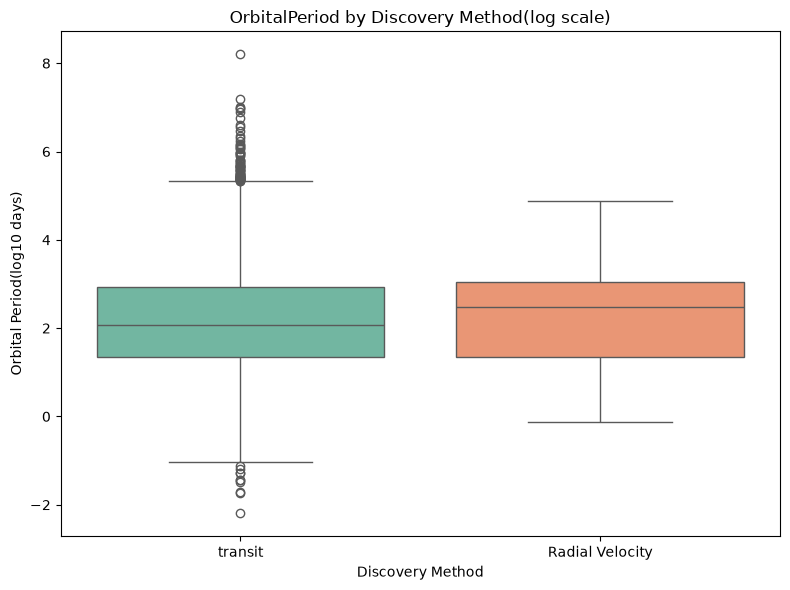

In [15]:
plt.figure(figsize=(8,6))
plot_df = pd.DataFrame({
    'Orbital Period(log10 days)':pd.concat([transit_log,rv_log]),
    'Discovery Method':['transit']*len(transit_log) +['Radial Velocity']*len(rv_log)})

sns.boxplot(data=plot_df,x='Discovery Method', y='Orbital Period(log10 days)',hue='Discovery Method',palette='Set2',legend=False)
plt.title('OrbitalPeriod by Discovery Method(log scale)')
plt.tight_layout()
plt.show()